# Compare unrealized gains PDFs

Load two `.h5` files, read only unrealized gains (aliases `unr_gains` / `unrealized_profits`), convert to M$, and plot both PDFs on one figure using the same smoothing/filters style as `generate_pdf_plot`.

In [19]:
from pathlib import Path

import h5py
import hdf5plugin  # noqa: F401
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, NullFormatter
import numpy as np
import pandas as pd
from scipy.stats import gaussian_kde

from ddstartup.utils.io_functions import h5_to_df_core

# ---- User inputs ----
H5_FILE_A = Path('test_parametric_lump/ddstartup_20251113_120706_parametric_lump.h5')
H5_FILE_B = Path('test_parametric_T_seeded/ddstartup_20251113_002935_parametric_T_seeded.h5')
OUTPUT_PNG = Path('outputs/compare_unrealized_gains.png')  # set to None to skip saving

# Variable and aliases to look for
VAR_NAME = 'unrealized_gains'
TARGET_COLUMNS = ('unrealized_profits',)
MASK_COLUMN = 'sol_success'

# Plot options (mimic generate_pdf_plot)
FILTERS = {VAR_NAME: {'min': None, 'max': None}}
SMOOTH = True
KDE_BANDWIDTH = 'scott'
LOG_X = True  # set False for linear x-axis


def _flatten_values(values: np.ndarray) -> np.ndarray:
    """Flatten object/array values to 1D numeric array."""
    if values.dtype == object:
        flat: list[float] = []
        for v in values:
            flat.extend(np.atleast_1d(v).ravel())
        values = np.asarray(flat)
    values = pd.to_numeric(pd.Series(values), errors='coerce').to_numpy(dtype=float)
    values = values[np.isfinite(values)]
    return values


def load_unrealized_gains_musd(h5_path: Path, verbose: bool = False) -> np.ndarray:
    """Load unrealized gains/profits from a run and return them in millions of dollars."""
    h5_path = Path(h5_path).expanduser()
    if not h5_path.exists():
        raise FileNotFoundError(f'missing file: {h5_path}')

    # Fast path: use h5_to_df_core on top-level datasets
    df = h5_to_df_core(
        h5_path,
        columns=list(TARGET_COLUMNS),
        verbose=False,
        downcast_float32=False,
    )
    col = next((c for c in TARGET_COLUMNS if c in df.columns), None)
    if col is not None:
        values = _flatten_values(df[col].to_numpy())
        if values.size:
            return values / 1e6
    # Fallback: direct h5py reader (similar to the diagnostic snippet)
    with h5py.File(h5_path, 'r') as h5:
        if verbose:
            keys = list(h5.keys())
            print(f"All column names in HDF5 file ({len(keys)}):")
            print(keys)

        mask = None
        if MASK_COLUMN in h5:
            try:
                mask_raw = h5[MASK_COLUMN][...]
                mask = mask_raw.astype(bool)
            except Exception:
                mask = None
            if verbose and mask is not None:
                print(f"Number of successful solutions: {int(mask.sum())} / {len(mask)}")

        dataset = None
        matched_name = None
        for colname in TARGET_COLUMNS:
            if colname in h5:
                dataset = h5[colname][...]
                matched_name = colname
                break
        if dataset is None:
            raise KeyError(f"Could not find any of {TARGET_COLUMNS} in {h5_path}")

        if verbose:
            print(f"Using dataset '{matched_name}' with shape {getattr(dataset, 'shape', None)}")

        data = np.asarray(dataset)
        if mask is not None and data.shape[0] == mask.shape[0]:
            data = data[mask]
        values = _flatten_values(data)
        if values.size == 0:
            raise ValueError(f'No finite unrealized gains found in {h5_path}')
        return values / 1e6

from pathlib import Path

import h5py
import hdf5plugin  # noqa: F401
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, NullFormatter
import numpy as np
import pandas as pd

from ddstartup.utils.io_functions import h5_to_df_core

# ---- NEW: LOWESS-based overlay ----
def add_trend_and_band(ax, x, y, color, label, frac=0.12, window_size=None, alpha_data=0.35, alpha_band=0.18):
    """
    Add LOWESS trend line and rolling-quantile uncertainty band on top of raw series.

    Args:
        ax: Matplotlib axis
        x: 1D array (assumed increasing)
        y: 1D array (same length as x)
        color: Matplotlib color
        label: Series label
        frac: LOWESS fraction parameter
        window_size: Rolling window size for uncertainty band (points)
        alpha_data: Alpha for raw line
        alpha_band: Alpha for band
    Returns:
        (line_raw, line_trend) handles
    """
    # Plot raw histogram-densities
    line_raw = ax.plot(x, y, color=color, linewidth=1.0, label=f"{label}", alpha=alpha_data, zorder=1)

    # Compute LOWESS trend (fallback to moving average if statsmodels unavailable)
    try:
        from statsmodels.nonparametric.smoothers_lowess import lowess
        trend = lowess(y, x, frac=frac, it=1, return_sorted=False)
    except Exception as e:
        print(f"Warning: LOWESS failed for {label}: {e}. Falling back to rolling mean.")
        win = max(5, len(x) // 50)
        trend = pd.Series(y, index=pd.Index(x, name="x")).rolling(win, center=True, min_periods=1).mean().to_numpy()

    # Plot trend
    line_trend = ax.plot(x, trend, color=color, linewidth=2.5, label=f"{label} (trend)", zorder=3)

    # Rolling-quantile band for local spread of residuals
    if window_size is None:
        window_size = max(25, len(x) // 20)  # adaptive
    min_periods = max(10, window_size // 3)

    residuals = pd.Series(y - trend, index=pd.Index(x, name="x"))
    lo_off = residuals.rolling(window_size, min_periods=min_periods).quantile(0.10)
    hi_off = residuals.rolling(window_size, min_periods=min_periods).quantile(0.90)

    lo = trend + lo_off.to_numpy()
    hi = trend + hi_off.to_numpy()

    ax.fill_between(x, lo, hi, color=color, alpha=alpha_band, linewidth=0, zorder=2)
    return line_raw, line_trend


# ---- Helpers for density on linear/log-x with adaptive binning ----
def _fd_nbins(x: np.ndarray, max_bins: int = 512, min_bins: int = 20) -> int:
    """Freedman–Diaconis rule → number of bins, bounded."""
    x = np.asarray(x)
    x = x[np.isfinite(x)]
    if x.size < 2:
        return 1
    iqr = np.subtract(*np.nanpercentile(x, [75, 25]))
    if iqr <= 0:
        # fallback: sqrt rule
        nb = int(np.clip(np.sqrt(x.size), min_bins, max_bins))
        return max(1, nb)
    h = 2 * iqr / np.cbrt(x.size)
    if h <= 0:
        return max(1, min_bins)
    nb = int(np.ceil((x.max() - x.min()) / h))
    return int(np.clip(nb, min_bins, max_bins))


def _hist_density(values: np.ndarray, log_x: bool, vmin=None, vmax=None, nbins: int | None = None):
    """
    Return (centers, density) for histogram (proper density: integrates to ~1),
    using equal-width bins in x (linear) or equal-width in log10(x) (log axes).
    """
    v = np.asarray(values, dtype=float)
    v = v[np.isfinite(v)]

    # Apply range filters
    if vmin is not None:
        v = v[v >= vmin]
    if vmax is not None:
        v = v[v <= vmax]

    if v.size < 2:
        return np.array([]), np.array([])

    if log_x:
        v = v[v > 0]
        if v.size == 0:
            return np.array([]), np.array([])
        lv = np.log10(v)
        if nbins is None:
            nbins = _fd_nbins(lv)
        # Equal-width bins in log10 → variable width in x; normalize by bin width in x
        lmin, lmax = np.min(lv), np.max(lv)
        edges = np.logspace(lmin, lmax, nbins + 1)
    else:
        if nbins is None:
            nbins = _fd_nbins(v)
        vmin_eff, vmax_eff = float(np.min(v)), float(np.max(v))
        edges = np.linspace(vmin_eff, vmax_eff, nbins + 1)

    counts, edges = np.histogram(v, bins=edges)
    widths = np.diff(edges)
    n = v.size
    # Proper density (probability per unit x):
    density = counts.astype(float) / (n * widths)
    centers = 0.5 * (edges[:-1] + edges[1:])
    # Remove empty bins for plotting clarity
    mask = np.isfinite(density) & (density > 0)
    return centers[mask], density[mask]


# ---- Replacement for plot_pdf_style ----
def plot_pdf_with_trend_band(
    data_dict: dict,
    var: str,
    labels: list[str],
    filters: dict,
    output_path,
    log_x: bool = True,
    frac: float = 0.12,
    window_size: int | None = None,
):
    """
    Plot histogram-based densities with LOWESS trend and rolling-quantile bands.
    Keeps raw structure; no KDE.
    """
    vmin = filters.get(var, {}).get('min') if filters else None
    vmax = filters.get(var, {}).get('max') if filters else None

    fig, ax = plt.subplots(figsize=(7, 5))
    has_data = False

    # Color cycle
    colors = plt.rcParams['axes.prop_cycle'].by_key().get('color', ['C0', 'C1', 'C2', 'C3'])

    for i, (fname, label) in enumerate(zip(list(data_dict.keys()), labels)):
        arr = np.asarray(data_dict[fname].get(var), dtype=float)
        if arr is None:
            continue
        arr = arr[np.isfinite(arr)]
        if arr.size == 0:
            continue

        centers, density = _hist_density(arr, log_x=log_x, vmin=vmin, vmax=vmax)
        if centers.size == 0:
            continue

        color = colors[i % len(colors)]
        add_trend_and_band(
            ax, centers, density, color=color, label=label, frac=frac, window_size=window_size
        )
        has_data = True

    ax.set_xlabel('Unrealized gains G [M$]')
    ax.set_ylabel('Probability Density')
    ax.set_title('Probability distribution of G')
    if has_data:
        ax.legend()
    if vmin is not None or vmax is not None:
        ax.set_xlim(left=vmin, right=vmax)
    if log_x:
        ax.set_xscale('log')
        ax.xaxis.set_major_locator(LogLocator(base=10.0, numticks=12))
        ax.xaxis.set_minor_formatter(NullFormatter())

    fig.tight_layout()
    if output_path:
        outp = Path(output_path)
        outp.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(outp, dpi=150)
        print(f"Saved plot to {outp}")
    #increase font size
    plt.rcParams.update({'font.size': 16})
    plt.show()



In [20]:
# Load unrealized gains (G) in millions of dollars from both files
G_a = load_unrealized_gains_musd(H5_FILE_A, verbose=True)
G_b = load_unrealized_gains_musd(H5_FILE_B, verbose=True)

print(f'Loaded {G_a.size} samples from {H5_FILE_A}')
print(f'Loaded {G_b.size} samples from {H5_FILE_B}')


   Loading chunks: 100%|██████████| 10/10 [00:00<00:00, 75.51chunk/s]

   Loading chunks: 100%|██████████| 13/13 [00:00<00:00, 176.75chunk/s]



Loaded 4633720 samples from test_parametric_lump/ddstartup_20251113_120706_parametric_lump.h5
Loaded 5943770 samples from test_parametric_T_seeded/ddstartup_20251113_002935_parametric_T_seeded.h5


Saved plot to outputs/compare_unrealized_gains.png


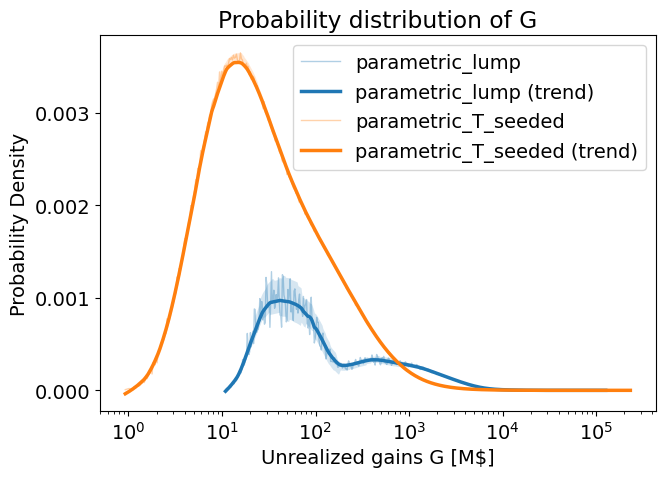

In [21]:

data_dict = {
    H5_FILE_A.name: {VAR_NAME: G_a},
    H5_FILE_B.name: {VAR_NAME: G_b},
}
labels = ['lump startup', 'T seeded startup']

plot_pdf_with_trend_band(
    data_dict,
    var=VAR_NAME,
    labels=["parametric_lump", "parametric_T_seeded"],
    filters=FILTERS,
    output_path=OUTPUT_PNG,
    log_x=LOG_X,
    frac=0.06,          # LOWESS smoothing fraction (smaller = less smoothing)
    window_size=None,   # auto
)


In [22]:
def pdf_area(x, y):
    x = np.asarray(x); y = np.asarray(y)
    m = np.isfinite(x) & np.isfinite(y)
    return float(np.trapz(y[m], x[m]))

# Example: reuse the same density you plot
areas = {}
for (fname, label) in zip(list(data_dict.keys()), labels):
    arr = np.asarray(data_dict[fname][VAR_NAME], dtype=float)
    centers, density = _hist_density(arr, log_x=LOG_X, vmin=FILTERS[VAR_NAME]['min'], vmax=FILTERS[VAR_NAME]['max'])
    areas[label] = pdf_area(centers, density)
print("Areas (should be ~1 unless you applied min/max filters):", areas)


/tmp/ipykernel_469528/329080633.py:4: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y[m], x[m]))


Areas (should be ~1 unless you applied min/max filters): {'lump startup': 1.0000971836556762, 'T seeded startup': 1.0001499672750858}
